# Pipeline

In [ ]:
# Loads relational tables into DuckDB, prepares data with SQL, and runs EDA

import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import logging

# Configuring logging
logging.basicConfig(
    filename='../.logs/pipeline.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# Loading relational tables into DuckDB
con = duckdb.connect()
try: 
    con.execute("CREATE TABLE transactions AS SELECT * FROM read_csv_auto('../data/relational/transactions.csv')")
    con.execute("CREATE TABLE transaction_types AS SELECT * FROM read_csv_auto('../data/relational/transaction_types.csv')")
    con.execute("CREATE TABLE time_steps AS SELECT * FROM read_csv_auto('../data/relational/time_steps.csv')")
    con.execute("CREATE TABLE accounts AS SELECT * FROM read_csv_auto('../data/relational/accounts.csv')")
    logging.info("Tables created successfully.")
except Exception as e:
    logging.error(f"Error creating tables: {e}")


# SQL query to prepare data for modeling
try:
    df = con.execute("""
        SELECT
          t.amount,
          t.isFraud,
          tt.type_name,
          ts.hour_of_day,
          ts.day_of_month,
          COALESCE(CASE WHEN a.account_type = 'merchant' THEN 1 ELSE 0 END, 0) AS is_merchant
        FROM transactions t
        JOIN transaction_types tt ON t.type_id = tt.type_id
        JOIN time_steps ts ON t.step = ts.step
        LEFT JOIN accounts a ON t.recipient_id = a.account_id
    """).df()
    logging.info(f"Query successful. DataFrame shape: {df.shape}")
except Exception as e:
    logging.error(f"Error executing SQL query: {e}")
    raise

# Performing brief EDA

print(df.shape)
print(df.isnull().sum())
print(df['isFraud'].value_counts())

(6362620, 6)
amount          0
isFraud         0
type_name       0
hour_of_day     0
day_of_month    0
is_merchant     0
dtype: int64
isFraud
0    6354407
1       8213
Name: count, dtype: int64


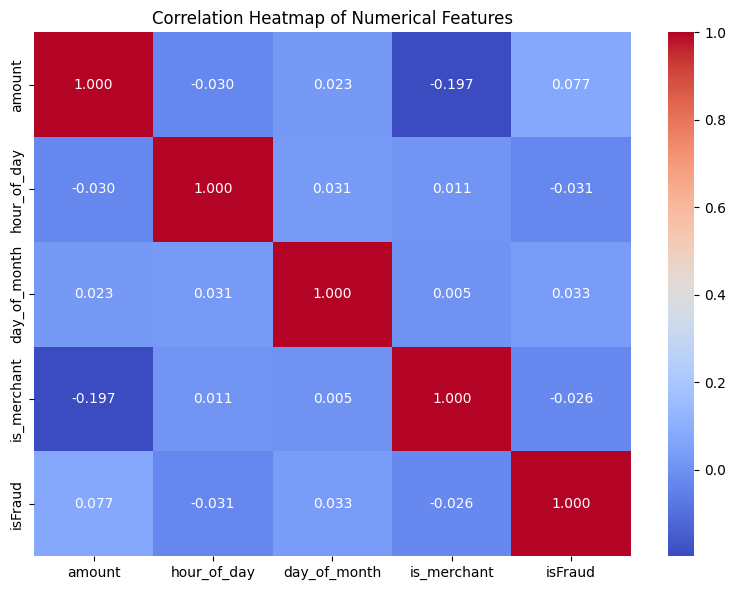

In [11]:
# Correlation heatmap of numerical features
corr = df[['amount', 'hour_of_day', 'day_of_month', 'is_merchant', 'isFraud']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [12]:
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, f1_score, precision_score, confusion_matrix

# Preparing features

df = pd.get_dummies(df, columns = ['type_name']) # Converting categorical columns to numeric
X = df.drop(columns = ['isFraud']) # Defining predictor variables
y = df['isFraud'] # Defining target variable

# Calculating scale_pos_weight to handle class imbalance
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = make_pipeline(StandardScaler(), XGBClassifier(scale_pos_weight = scale_pos_weight, random_state = 42)) # Instantiating the model

# Hyperparameter tuning with GridSearchCV
param_grid = {
    'xgbclassifier__n_estimators': [100, 200],
    'xgbclassifier__max_depth': [3, 5],
    'xgbclassifier__learning_rate': [0.01, 0.1]
}

# Using StratifiedKFold to maintain class distribution in folds and optimizing for recall
grid_search = GridSearchCV(
    estimator=model, 
    param_grid=param_grid, 
    cv=StratifiedKFold(n_splits=3), 
    scoring='recall', 
    n_jobs=1,
    verbose=3
)

grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV 1/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=100;, score=0.899 total time=   4.1s
[CV 2/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=100;, score=0.916 total time=   4.0s
[CV 3/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=100;, score=0.890 total time=   4.4s
[CV 1/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=200;, score=0.899 total time=   6.5s
[CV 2/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=200;, score=0.905 total time=   6.6s
[CV 3/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=3, xgbclassifier__n_estimators=200;, score=0.890 total time=   6.7s
[CV 1/3] END xgbclassifier__learning_rate=0.01, xgbclassifier__max_depth=5, xgbclassifier__n_e

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'xgbclassifier__learning_rate': [0.01, 0.1], 'xgbclassifier__max_depth': [3, 5], 'xgbclassifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computati

In [16]:
# Best model and its performance
print("Best Hyperparameters:", grid_search.best_params_)
print("Recall:", grid_search.best_score_)

Best Hyperparameters: {'xgbclassifier__learning_rate': 0.1, 'xgbclassifier__max_depth': 3, 'xgbclassifier__n_estimators': 100}
Recall: 0.9079102483303263


In [17]:
# Evaluating the best model on the test set

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test Set Recall: {recall:.4f}")
print(f"Test Set Precision: {precision:.4f}")
print(f"Test Set F1 Score: {f1:.4f}")

Test Set Recall: 0.9069
Test Set Precision: 0.0113
Test Set F1 Score: 0.0222


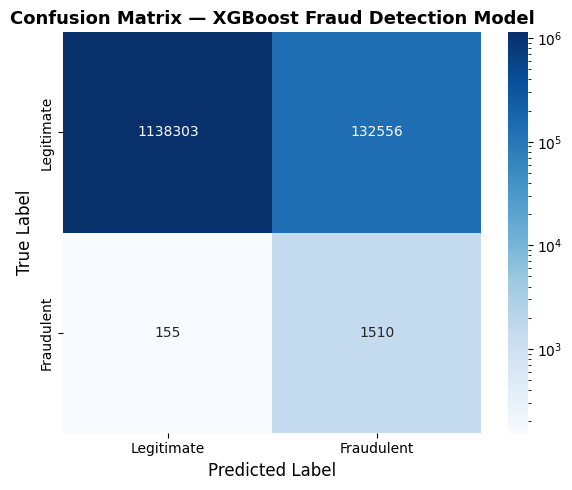

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

# Visualizing confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'],
            norm=LogNorm())
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — XGBoost Fraud Detection Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()